# E-commerce User Behaviour Analysis

This project explores how users interact with an online cosmetics platform, focusing on how they move from browsing products to making a purchase.

## Data Loading

In [1]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("data/2019-Nov.csv", nrows=100000)

df.head()


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:02 UTC,view,5802432,1487580009286598681,NaN,NaN,0.32,562076640,09fafd6c-6c99-46b1-834f-33527f4de241
1,2019-11-01 00:00:09 UTC,cart,5844397,1487580006317032337,NaN,NaN,2.38,553329724,2067216c-31b5-455d-a1cc-af0575a34ffb
2,2019-11-01 00:00:10 UTC,view,5837166,1783999064103190764,NaN,pnb,22.22,556138645,57ed222e-a54a-4907-9944-5a875c2d7f4f
3,2019-11-01 00:00:11 UTC,cart,5876812,1487580010100293687,NaN,jessnail,3.16,564506666,186c1951-8052-4b37-adce-dd9644b1d5f7
4,2019-11-01 00:00:24 UTC,remove_from_cart,5826182,1487580007483048900,NaN,NaN,3.33,553329724,2067216c-31b5-455d-a1cc-af0575a34ffb


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     100000 non-null  object 
 1   event_type     100000 non-null  object 
 2   product_id     100000 non-null  int64  
 3   category_id    100000 non-null  int64  
 4   category_code  1614 non-null    object 
 5   brand          60918 non-null   object 
 6   price          100000 non-null  float64
 7   user_id        100000 non-null  int64  
 8   user_session   99956 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 6.9+ MB


## Data Preparation

In [3]:
# Convert time
df['event_time'] = pd.to_datetime(df['event_time'])

# Keep only key events
df = df[df['event_type'].isin(['view', 'cart', 'purchase'])]

df = df[df['price'] > 0]

# Drop missing users
df = df.dropna(subset=['user_id'])

## Data Preparation Insight
The dataset contains missing values in certain descriptive fields such as product category and brand. However, core behavioral variables such as event type, timestamp, and user identifiers are complete, allowing for reliable analysis of user interaction patterns.

## Event Distribution

In [4]:
df['event_type'].value_counts(normalize=True)

event_type
view        0.566842
cart        0.352009
purchase    0.081149
Name: proportion, dtype: float64

## Event Distribution Insight

The distribution of user interactions reveals that a significant proportion of users progress from viewing products to adding them to the cart. However, a substantial drop off occurs at the final stage of the funnel, with only a small percentage of users completing purchases. 

This suggests that while user interest and intent are relatively high, barriers exist at the point of conversion. These may include price sensitivity, hesitation in decision-making, or friction in the checkout process.

## Funnel Analysis

In [5]:
user_funnel = df.pivot_table(
    index='user_id',
    columns='event_type',
    aggfunc='size',
    fill_value=0
)

user_funnel['viewed'] = user_funnel['view'] > 0
user_funnel['carted'] = user_funnel['cart'] > 0
user_funnel['purchased'] = user_funnel['purchase'] > 0

In [6]:
view_to_cart = user_funnel['carted'].sum() / user_funnel['viewed'].sum()
cart_to_purchase = user_funnel['purchased'].sum() / user_funnel['carted'].sum()
view_to_purchase = user_funnel['purchased'].sum() / user_funnel['viewed'].sum()

view_to_cart, cart_to_purchase, view_to_purchase

(0.2723769768001927, 0.23430592396109637, 0.06381953921489926)

## Funnel Analysis

Around 27% of users who view products go on to add items to their cart, which shows that users are genuinely interested and willing to explore products further.

This was interesting because I initially expected more users to drop off earlier in the funnel, but instead most users reach the cart stage.

However, only about 23% of those users actually complete a purchase, leading to an overall conversion rate of roughly 6%. This suggests that even though users are interested, many do not follow through to complete the purchase.

The biggest drop happens at the cart stage, which may be due to factors like price concerns, hesitation, or issues during checkout.

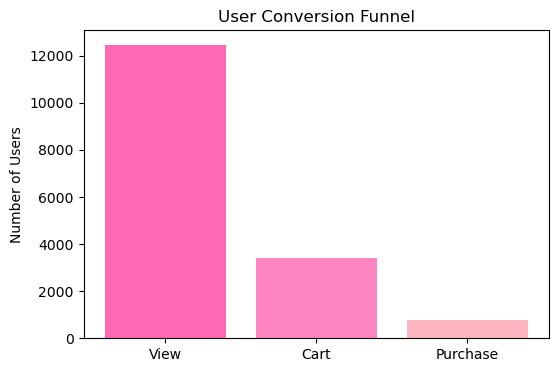

In [7]:
import matplotlib.pyplot as plt

stages = [
    user_funnel['viewed'].sum(),
    user_funnel['carted'].sum(),
    user_funnel['purchased'].sum()
]

labels = ['View', 'Cart', 'Purchase']

plt.figure(figsize=(6,4))

plt.bar(labels, stages, color=['#ff69b4', '#ff85c1', '#ffb6c1'])

plt.title("User Conversion Funnel")
plt.style.use('ggplot')
plt.ylabel("Number of Users")

plt.show()

## Time to Purchase Analysis

In [8]:
first_view = df[df['event_type']=='view'].groupby('user_id')['event_time'].min()
first_purchase = df[df['event_type']=='purchase'].groupby('user_id')['event_time'].min()

time_diff = (first_purchase - first_view).dropna()

time_diff = time_diff.dt.total_seconds() / 3600

# remove invalid negative values
time_diff = time_diff[time_diff >= 0]

time_diff.describe()

count    675.000000
mean       1.463640
std        2.389858
min        0.008333
25%        0.185694
50%        0.515000
75%        1.493056
max       18.288056
Name: event_time, dtype: float64

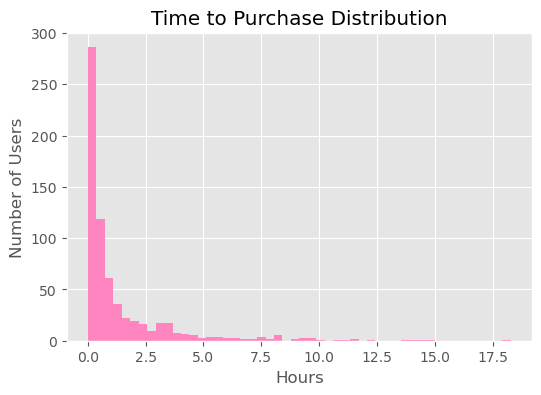

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(time_diff, bins=50, color='#ff85c1')

plt.title("Time to Purchase Distribution")
plt.xlabel("Hours")
plt.ylabel("Number of Users")

plt.show()

## Time to Purchase Insight

The data shows that most users complete their purchase quite quickly after viewing a product, often within the first hour. This suggests that many decisions are made fast, without much delay.

However, some users take longer to complete their purchase, which may mean they are comparing options or returning later before making a decision.

Overall, this shows that there are two types of behavior: some users make quick decisions, while others take more time before buying.

## Repeat User Analysis(New vs Repeat Users)

In [10]:
user_counts = df.groupby('user_id').size()

repeat_users = user_counts[user_counts > 5].index
df['repeat_user'] = df['user_id'].isin(repeat_users)

df.groupby('repeat_user')['event_type'].value_counts(normalize=True)


repeat_user  event_type
False        view          0.880564
             cart          0.111714
             purchase      0.007723
True         view          0.481132
             cart          0.417659
             purchase      0.101210
Name: proportion, dtype: float64

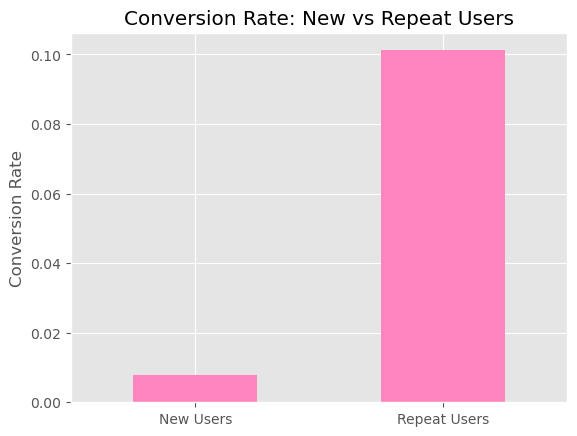

In [11]:
df['converted'] = df['event_type'] == 'purchase'

conversion = df.groupby('repeat_user')['converted'].mean()

conversion.index = ['New Users', 'Repeat Users']

conversion.plot(kind='bar', color='#ff85c1')
plt.title('Conversion Rate: New vs Repeat Users')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()

In [12]:
conversion_rates = df.groupby('repeat_user')['converted'].mean()
print(conversion_rates)

repeat_user
False    0.007723
True     0.101210
Name: converted, dtype: float64


In [13]:
ratio = conversion_rates[True] / conversion_rates[False]
print(ratio)

13.10547835850999


## Repeat User Behavior Insight

The analysis reveals a clear difference between new and repeat users. New users primarily engage in browsing behavior, with a very small proportion completing purchases. In contrast, repeat users show significantly higher engagement, with a much larger share progressing to cart and purchase stages.

Notably, repeat users are far more likely to complete a purchase compared to new users. This suggests that familiarity with the platform, trust, and prior experience play a crucial role in driving conversions.

Repeat users are approximately 13 times more likely to convert than new users, highlighting the strong impact of familiarity and trust on purchase behaviour.

These findings highlight the importance of user retention strategies, as returning users contribute disproportionately to actual purchases.

## Price Analysis

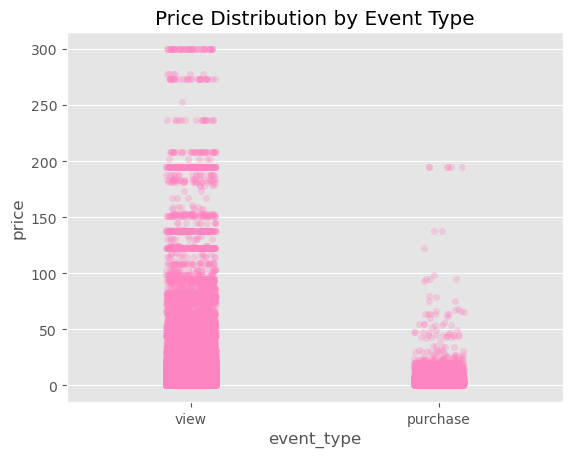

In [14]:

price_df = df[df['event_type'].isin(['view', 'purchase'])]

sns.stripplot(x='event_type', y='price', data=price_df, alpha=0.3, color='#ff85c1')
plt.title('Price Distribution by Event Type')
plt.show()

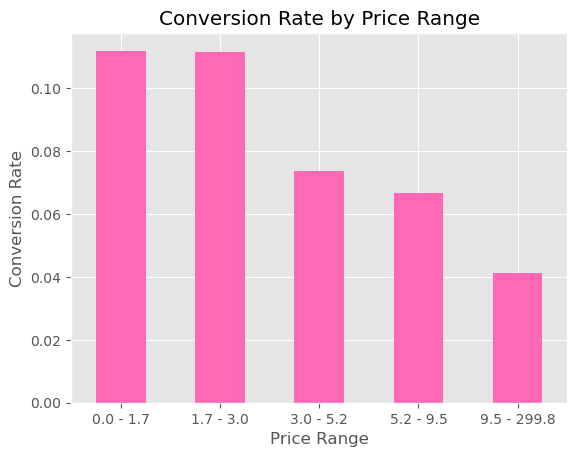

In [15]:

df['converted'] = df['event_type'] == 'purchase'

# Create bins
df['price_bin'] = pd.qcut(df['price'], q=5)

df['price_bin'] = df['price_bin'].apply(lambda x: f"{round(x.left,1)} - {round(x.right,1)}")

ax = df.groupby('price_bin', observed=True)['converted'].mean().plot(
    kind='bar',
    color='#ff69b4'
)

plt.title('Conversion Rate by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)

plt.show()

In [16]:
price_conv = df.groupby('price_bin', observed=True)['converted'].mean()
print(price_conv)

low = price_conv.iloc[0]
high = price_conv.iloc[-1]

drop = ((low - high) / low) * 100
print(drop)

price_bin
0.0 - 1.7      0.111910
1.7 - 3.0      0.111383
3.0 - 5.2      0.073685
5.2 - 9.5      0.066580
9.5 - 299.8    0.041312
Name: converted, dtype: float64
63.08436436983983


In [17]:
from sklearn.linear_model import LogisticRegression

df['converted'] = (df['event_type'] == 'purchase').astype(int)

X = df[['price']]
y = df['converted']

model = LogisticRegression()
model.fit(X, y)

print("Coefficient:", model.coef_[0][0])

Coefficient: -0.03963747450600246


A simple logistic regression model further supports this relationship, showing that higher prices are associated with a lower likelihood of conversion.

## Price Analysis Insight

The price analysis shows that users often view higher priced products, but tend to purchase cheaper ones.

This suggests that while users are interested in more expensive items, they may hesitate when it comes to actually buying them. Instead, they choose more affordable options.

Conversion rates in higher price ranges are approximately 63% lower than in lower price ranges, indicating a strong negative relationship between price and purchase likelihood.

This also helps explain some of the drop off in the funnel, especially at the final stage, where price may influence the decision to complete a purchase.

## Conclusion

This analysis shows that while many users engage with products and progress to the cart stage, only a smaller proportion complete purchases, resulting in an overall conversion rate of approximately 6%. This indicates that the primary drop-off occurs at the final stage of the funnel. Although users demonstrate strong initial interest, a significant number do not follow through, suggesting that improving the checkout or decision stage could significantly increase overall conversion rates.

The time to purchase analysis further reveals two distinct behavioural patterns. Many users complete purchases quickly, often within the first hour, indicating fast decision making. In contrast, a smaller group of users take longer, suggesting more deliberate behaviour such as comparing options or returning later. This highlights variation in user intent and decision processes across the platform.

The price analysis shows that conversion rates decline as price increases, with higher price ranges exhibiting approximately 63% lower conversion compared to lower price ranges. This indicates that price sensitivity plays an important role in influencing final purchase decisions and may contribute to drop offs at later stages of the funnel.

In addition, repeat users exhibit significantly higher engagement and conversion compared to new users, being approximately 13 times more likely to convert. This highlights the importance of familiarity and trust in driving purchases.

Overall, this analysis demonstrates how user behaviour evolves across different stages of the purchase journey and highlights the measurable impact of factors such as price, decision timing, and repeat interaction on conversion outcomes.